In [1]:
import pybamm
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt

# # import  settings
import plot_settings
plot_settings.apply()

In [48]:
def simulate(I0):
    model = pybamm.lithium_ion.SPM()
    param = model.default_parameter_values
    def my_current(t, I0=I0):
        return I0
    
    param["Current function [A]"] = my_current

    param.process_model(model)
    geometry = model.default_geometry
    param.process_geometry(geometry)
    mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
    disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
    disc.process_model(model)
    t_eval = [0,3*3600]

    solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
    solution = solver.solve(model, t_eval)

    return solution,model


def get_data(I):
    solution, model = simulate(I)
    c_p = solution.observe(model.variables['Positive particle concentration [mol.m-3]'])
    tf = int(solution['Time [s]'].entries[-1]/2)
    t_ = np.linspace(0,solution['Time [s]'].entries[-1], tf)
    dt = t_[1] - t_[0]
    

    feature = np.zeros((tf,21))
    for t in trange(tf):
        feature[t,1:] = c_p(t_)[:,0,t].flatten()
        feature[t,0] = I
    #feature  = np.array([c_p(t_)[:,0,0], I * np.ones(len(t_))])
    #target = c_p(t_)[:,0,1:]
    d = np.mean(feature[1:,1:] - feature[:-1,1:],axis = 1)
    c_old = np.mean(feature[:-1,:],axis =1)
    c_new = np.mean(feature[1:,:],axis =1)
    return c_old,c_new,d / dt, dt
I0 = 1.0
co,cn,cd,dt = get_data(I0)

# def get_data(I):
#     solution, model = simulate(I)
#     c_p = solution.observe(model.variables['Positive particle concentration [mol.m-3]'])
#     t_ = np.linspace(0,solution['Time [s]'].entries[-1],101)
#     t_f = solution['Time [s]'].entries[-1]

#     df_feature = pd.DataFrame(columns=['c_p0','I','t'])
#     df_feature['c_p0'] = c_p(t_)[0,0,0]
#     df_feature['t'] = t_f* np.ones_like(df_feature['c_p0'])
#     df_feature['I'] = I * np.ones_like(df_feature['c_p0'])
    
#     feature  = np.array([c_p(t_)[0,0,0], I, t_f])
#     target = c_p(t_)[:,0,1:]
#     return feature* np.ones((100,3)), target.T 


# X = np.zeros((len(np.arange(0,41)),100,3))
# y = np.zeros((len(np.arange(0,41)),100,20))
# for i in np.arange(0,41):
#     i0 = np.round(0.05 * i,2)
#     data = get_data(i0)
#     X[i,:,:] = data[0]
#     y[i,...] = data[1]


100%|██████████| 1219/1219 [00:02<00:00, 417.61it/s]


In [49]:
df_data = pd.DataFrame(columns = ['I','co','cn','c-dot','dt'])
df_data['I'] = np.ones_like(co) * I0
df_data['co'] = co
df_data['cn'] = cn
df_data['c-dot'] = cd
df_data['dt'] = dt
#df = pd.DataFrame(data,columns = ['co','cn','c-dot','dt'])

display(df_data)

df_data.to_csv('data/df_c_dot.csv')

,I,co,cn,c-dot,dt
0,1.0,29267.433751,29272.490645,2.650560,2.003251
1,1.0,29272.490645,29277.805731,2.785891,2.003251
2,1.0,29277.805731,29283.333555,2.897397,2.003251
3,1.0,29283.333555,29289.044637,2.993452,2.003251
4,1.0,29289.044637,29294.913005,3.075893,2.003251
...,...,...,...,...,...
1213,1.0,45874.507209,45888.452383,7.309333,2.003251
1214,1.0,45888.452383,45902.397557,7.309333,2.003251
1215,1.0,45902.397557,45916.342731,7.309333,2.003251
1216,1.0,45916.342731,45930.287906,7.309333,2.003251


In [38]:
i = [0.25,0.5,0.75,0.76,1.0,1.25,1.5,1.75,2.0]
for i0,t in zip(i,trange(len(i))):
    feature, target = get_data(i0)
    mean_c = np.zeros((len(target),2))
    np.savez(f'data/{i0}_feature.npz',feature)
    np.savez(f'data/{i0}_target.npz', target)
    mean_c[:,0] = np.mean(target, axis=1)
    mean_c[:,1] = i0 * np.ones_like(mean_c[:,1])
    np.savez(f'data/{i0}_mean_target.npz', mean_c)

 89%|████████▉ | 8/9 [00:51<00:06,  6.49s/it]


[3.65547671 3.65547671]
[14.50361144  0.06812889]


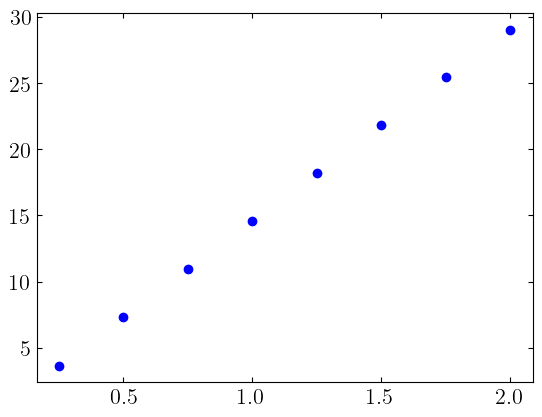

In [15]:
ks = np.zeros((len(i),2))

for n,i0 in enumerate(i):
    data = np.load(f'data/{i0}_mean_target.npz')
    t = np.arange(len(data['arr_0'][:,0]))
    k = np.polyfit(t,data['arr_0'][:,0],1)
    plt.scatter(i0,k[0],color='blue')
    ks[n] = k[0]
print(ks[0])
k_i = np.polyfit(i,ks[:,0],1)
print(k_i)

In [24]:
def predict_c(t,I,c0=0):
    return (k_i[0] * I) * t + c0

Text(0.5, 0, 'Time [s]')

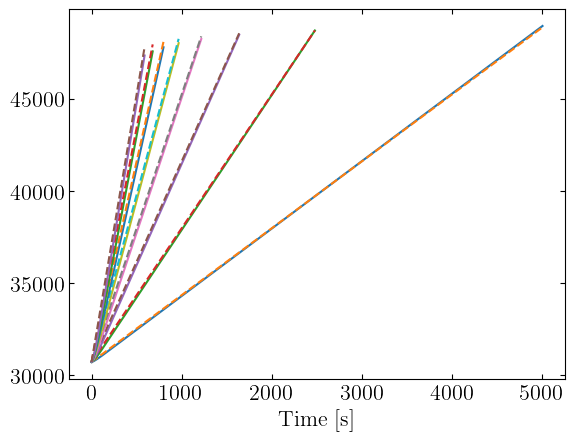

In [35]:
for I in i:
    y_real = np.load(f'data/{I}_mean_target.npz')['arr_0'][:,0]
    t = np.arange(len(y_real))
    y_pred = predict_c(t,I,c0=y_real[0])
    #plt.plot(t,(y_real-y_pred)/np.mean(y_real),label=f'$I={I}$')
    plt.plot(t,y_real,label=f'Real $I={I}$')
    plt.plot(t,y_pred,'--',label=f'Predicted $I={I}$')
plt.xlabel('Time [s]')

In [548]:
#pybamm.sin(20 *np.pi* t / (3600)) + 1  # Example: sinusoidal current

param["Current function [A]"] = my_current


param.process_model(model)
param.process_geometry(geometry)

mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)

disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model)

In [549]:
# solve model
t_eval = np.linspace(0, 3600, 100)
t_eval = [0,3*3600]
solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
solution = solver.solve(model, t_eval)

In [550]:
# # variables
# for k, v in zip(model.variables.keys(), model.variables.values()):
#     print(f"{k}\t\t{v}")

# model.print_parameter_info()
# print(param)

for var, eq in model.rhs.items():
    print(var, eq)

Discharge capacity [A.h] Column vector of length 1
Throughput capacity [A.h] Column vector of length 1
X-averaged negative particle concentration [mol.m-3] Column vector of length 20 + Sparse Matrix (20, 20) @ y[2:22]
X-averaged positive particle concentration [mol.m-3] Column vector of length 20 + Sparse Matrix (20, 20) @ y[22:42]


In [551]:
# plot = pybamm.QuickPlot(solution,
#                     output_variables=[
#                         "Negative particle concentration [mol.m-3]",
#                         "Positive particle concentration",
#                         "Negative electrode potential [V]",
#                         "Positive electrode potential [V]",
#                         "Electrolyte concentration [mol.m-3]",
#                         "Voltage [V]",
#                         "Current [A]",
#                     ])
# plot.dynamic_plot()

In [552]:
# n = 0
# f, ax = plt.subplots(int(138/2),2,figsize=(6,int(138*3)))
# for i,vals in enumerate(model.variables.keys()):
    
#     if solution[vals].entries.ndim == 1:
#         if solution[vals].entries[0] != solution[vals].entries[-1]:
            
#             if n % 2 == 1:
#                 j = 1
#             else:
#                 j = 0
            
#             ax[int(n/2),j].plot(solution["Time [s]"].entries, solution[vals].entries, label=vals)
#             ax[int(n/2),j].legend(fontsize=6)
#             n += 1
# plt.savefig('prg_figs/all_t_vars.pdf', bbox_inches='tight')
# plt.show()
#     #print(f'{solution[vals].entries.shape} \t {vals}')
# print(f'Total number of variables: {n}')

In [553]:
# n = 0

# t0 = 0; x0= 0
# f, ax = plt.subplots(int(20/2),2,figsize=(6,int(20*3)))
# for t0 in [0,-1]:
#     n = 0   
#     for i,vals in enumerate(model.variables.keys()):
        
#         if solution[vals].entries.shape[0] ==  solution['r_n [m]'].entries.shape[0]:
#             print(vals)
#             #if solution[vals].entries[0] != solution[vals].entries[-1]:

#             if n % 2 == 1:
#                     j = 1
#             else:
#                     j = 0
#             if solution[vals].entries.ndim == 2:
#                 ax[int(n/2),j].plot(solution["r_n [m]"].entries[:,x0,t0], solution[vals].entries[:,t0], label=vals)
#                 ax[int(n/2),j].legend(fontsize=6)
#             elif solution[vals].entries.ndim == 3:
#                 ax[int(n/2),j].plot(solution["r_n [m]"].entries[:,x0,t0], solution[vals].entries[:,x0,t0], label=vals)
#                 ax[int(n/2),j].legend(fontsize=6)
#             n += 1

# plt.savefig('prg_figs/all_r_vars.pdf', bbox_inches='tight')
# #plt.show()
#     #print(f'{solution[vals].entries.shape} \t {vals}')
print(f'Total number of variables: {n}')

Total number of variables: 20


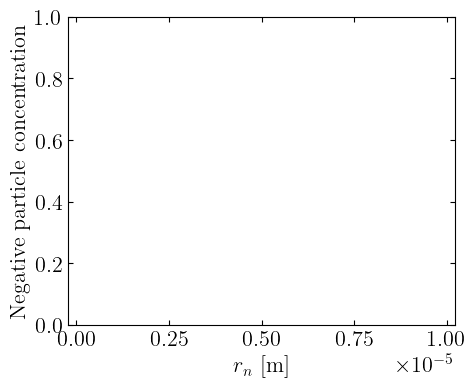

In [554]:
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries[:, 0,1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

def plot_concentrations(t):
    fig, ax1 = plt.subplots(1, 1, figsize=(5, 4))
    
    # Evaluate concentration at specific time and x position (returns values at all r points)
    c_vals = c_s_n(r=r_n, t=t, x=x[0])
    
    # Get the r coordinate values - use entries to get the proper array shape
    r_vals = c_s_n.entries[:, 0, 0]  # Get r values from the data structure
    
    (_plot_c_n,) = ax1.plot(r_n, c_vals)
    ax1.set_ylabel("Negative particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax1.set_ylim(0, 1)

plot_concentrations(t=1800)  # plot at 1800 s

Text(0.5, 1.0, 'Negative particle concentration at $t$')

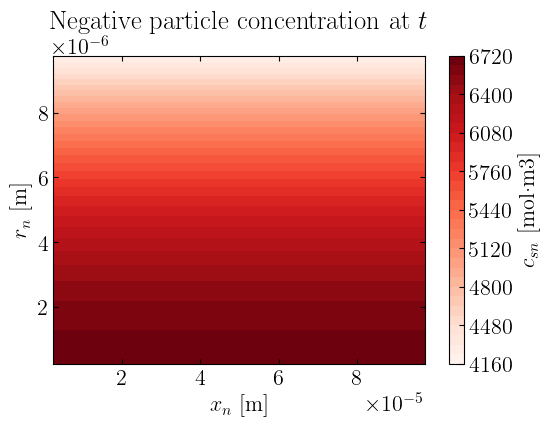

In [555]:
import matplotlib as mpl

# Solution variables
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))

# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
r2d = r_n[..., ti]    # shape (nr, nx)
x2d = x_n[..., ti]    # shape (nx,)

# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[..., ti]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
X, R = np.meshgrid(x2d, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(X, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$x_n$ [m]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at $t$")

(36,)
(20, 20, 36)
(20, 20, 36)


Text(0.5, 1.0, 'Negative particle concentration at t')

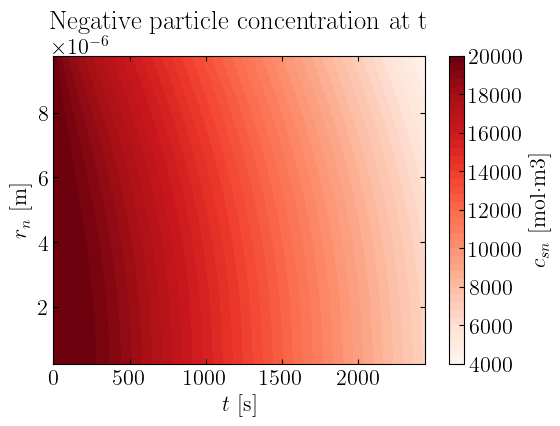

In [556]:
c_s_n = solution["Negative particle concentration [mol.m-3]"].entries
r_n = solution["r_n [m]"].entries 
t_vals = solution["Time [s]"].entries  
print(t_vals.shape)
print(r_n.shape)
print(c_s_n.shape)


t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))



xi =19
r2d = r_n[:,xi,:]    # shape (nr, nx)
c2d = c_s_n[:,xi,:]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
T, R = np.meshgrid(t_vals, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(T, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$t$ [s]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at t")



(100,)


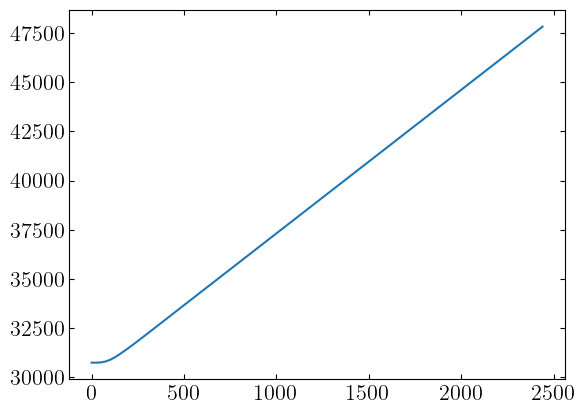

In [ ]:
npc = solution.observe(model.variables['Positive particle concentration [mol.m-3]'])

t_ = np.linspace(0,solution['Time [s]'].entries[-1],101)
plt.plot(t_,npc(t_)[0,0,:])

print(npc(t_)[0,0,:].shape)

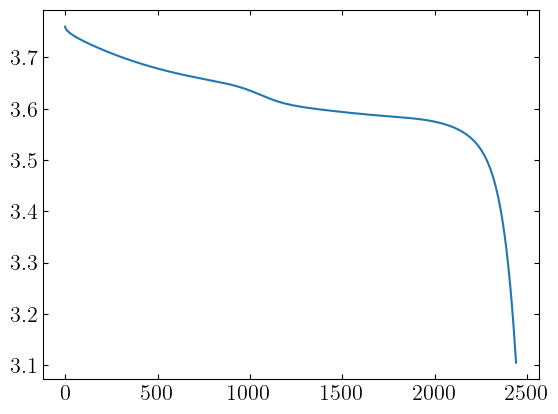

In [558]:
V = solution.observe(model.variables['Voltage [V]'])

t_ = np.linspace(0,solution['Time [s]'].entries[-1],int(solution['Time [s]'].entries[-1]))
plt.plot(t_,V(t_))



Text(0, 0.5, 'Normalized surface concentration')

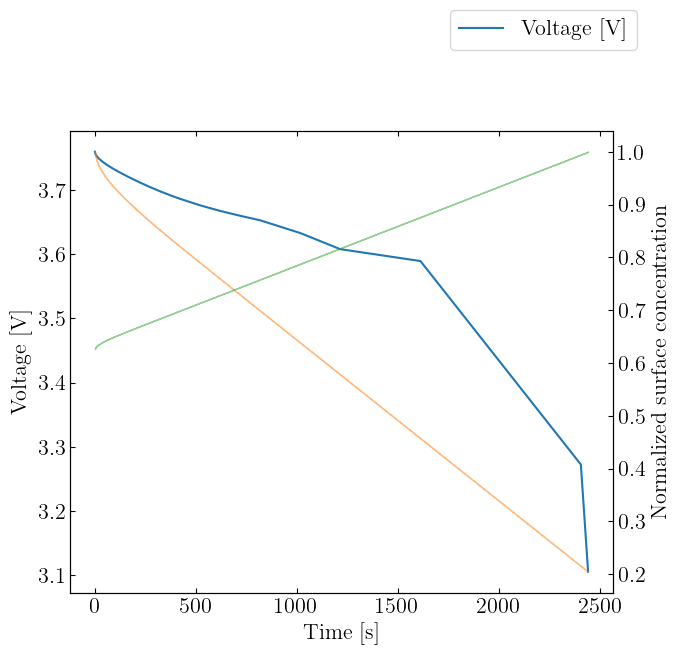

In [559]:
plot2 = 'Negative particle surface concentration [mol.m-3]'

T = solution["Time [s]"].entries
cn = solution[plot2].entries
cp = solution['Positive particle surface concentration [mol.m-3]'].entries
V = solution["Terminal voltage [V]"].entries

f,ax = plt.subplots(1,1,figsize=(7,6))
ax1 =ax.twinx()
ax.plot(T,V,color = 'tab:blue',label = 'Voltage [V]')

ax1.fill_between(T,cn[0]/np.max(cn[0]),cn[-1]/np.max(cn[-1]),color = 'tab:orange',alpha=0.5)
ax1.fill_between(T,cp[0]/np.max(cp[0]),cp[-1]/np.max(cp[-1]),color = 'tab:green',alpha=0.5)
#ax1.plot(T,solution[''].entries,color='tab:orange',label='Neg. particle surf. conc.'   )
    
    #ax1.plot(T,cp[r]/np.max(cp[r]) - cn[r]/np.max(cn[r]),color = 'tab:red')
f.legend(bbox_to_anchor=(0.95,1.1))    
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax1.set_ylabel('Normalized surface concentration')